## Beta

* When considering "stock picking" one factor you might consider is how the stock has performed versus de market in the past
* Is the slope of the regression line when use the "market" as a predictor for the stock you are interested in
* Beta higher than 1 suggests that the stock outperform the market - however ir also suggerst in a fown period the stock will inderperform the market.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yfi
%matplotlib inline

[*********************100%***********************]  2 of 2 completed

<class 'pandas.DataFrame'>
DatetimeIndex: 135 entries, 2015-01-30 to 2026-03-31
Freq: BME
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    135 non-null    float64
 1   ^GSPC   135 non-null    float64
dtypes: float64(2)
memory usage: 3.2 KB
[1.18633771]


array([0.01813696])

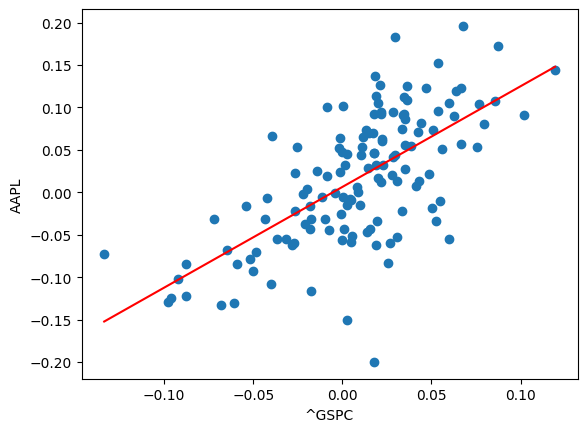

In [36]:
stocks = '^GSPC AAPL'.split()
data= yfi.download(stocks, start='2015-01-01')['Close']
data = data.resample('BME').last()
data.tail()
data.info()
change = pd.DataFrame()
for column in data:
    if column not in change:
        change[column] = np.log(data[column]).diff()
change = change[1:]
from sklearn.linear_model import LinearRegression as lr
model = lr(fit_intercept=True)
x = np.array(change['^GSPC'])
y = np.array(change['AAPL'])
model.fit(x[:,np.newaxis],y)

xfit = np.linspace(x.min(), x.max(), 100)
yfit = model.predict(xfit[:,np.newaxis])
plt.scatter(x,y)
plt.plot(xfit, yfit, c='r')
plt.ylabel('AAPL')
plt.xlabel('^GSPC')

print(model.coef_)
model.predict([[.01]])
